In [ ]:
import sys
import os
sys.path.append(os.path.abspath('../..'))
from src.models.v3.n_gram_network import Tokenizer, NGramNetwork
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Initializations for network

data_path = '../../src/data/normalized/en_cities.txt'
tokenizer = Tokenizer(data_path)
network = NGramNetwork(4, tokenizer, data_path, embedding_vector_size=2, w1_out=256)
print('Number of parameters:', sum(p.nelement() for p in network.parameters))

Number of parameters: 9556


In [3]:
# Training

print('\nFirst iterations with learning rate 0.1')
network.train(iterations=50_000, learning_rate_function=lambda _:0.1)

print('\nSecond iterations with learning rate 0.05')
network.train(iterations=15_000, learning_rate_function=lambda _:0.05)

print('\nThird iterations with learning rate 0.01')
network.train(iterations=15_000, learning_rate_function=lambda _:0.01)


First iterations with learning rate 0.1
Iteration      0: loss=27.893877029418945
Iteration      1: loss=22.382762908935547
Iteration      2: loss=20.39935302734375
Iteration      3: loss=20.431135177612305
Iteration      4: loss=23.33548355102539
...
Iteration  49996: loss=2.3057820796966553
Iteration  49997: loss=2.1170647144317627
Iteration  49998: loss=2.1681857109069824
Iteration  49999: loss=2.527662992477417

Second iterations with learning rate 0.05
Iteration  50000: loss=2.4686014652252197
Iteration  50001: loss=1.948801875114441
Iteration  50002: loss=1.8413054943084717
Iteration  50003: loss=2.547940731048584
Iteration  50004: loss=2.265841245651245
...
Iteration  64996: loss=2.230591297149658
Iteration  64997: loss=1.987518310546875
Iteration  64998: loss=2.5525317192077637
Iteration  64999: loss=2.292933940887451

Third iterations with learning rate 0.01
Iteration  65000: loss=2.1251943111419678
Iteration  65001: loss=2.138549327850342
Iteration  65002: loss=1.82324159145

In [4]:
print('Loss on test set:', network.evaluate_test_set())

Loss on test set: 2.2591609954833984


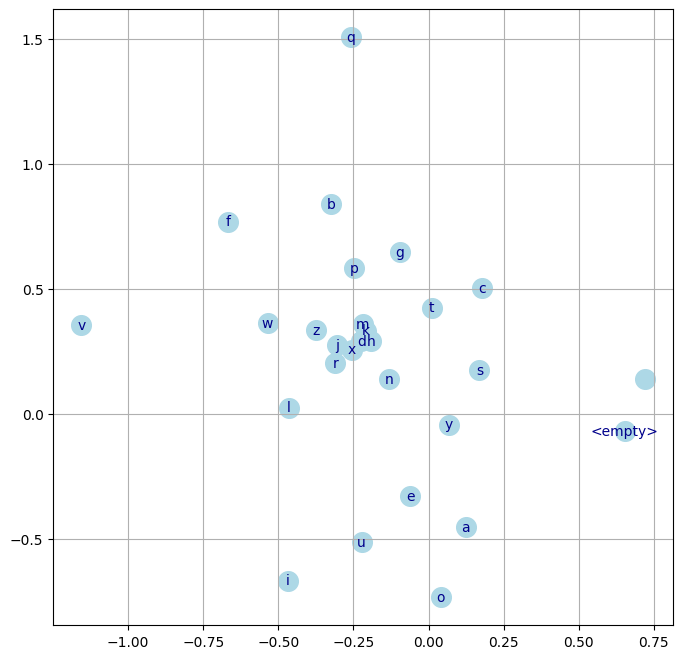

In [5]:
# Figure of embeddings

plt.figure(figsize=(8, 8))
plt.scatter(network.C[:, 0].data, network.C[:, 1].data, s=200, color='lightblue')
for i in range(network.C.shape[0]):
    plt.text(network.C[i, 0].item(), network.C[i, 1].item(), tokenizer.itos[i], ha='center', va='center', color='darkblue')
plt.grid('minor')
plt.show()

In [6]:
def sample_word(net:NGramNetwork):
    context = [0] * net.CONTEXT_SIZE
    i = None
    out = []
    while i != 0:
        i = net.sample(context)
        context = context[1:] + [i]
        out.append(i)
    print(tokenizer.decode(out))

In [7]:
# Sampling

for _ in range(10):
    sample_word(network)

palm
ebringer
nurs
elbaroutonnerlinga
conker
pere cribudsrame
oem
envey
farickidghomps
horie lenmaleigonnen
